# 23 Feb 2026
- assigning positions to the CVs based on prescriptions from Scaringi et al. 2023

In [23]:
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import copy
import corner
import astropy.coordinates as cc
import healpy as hp


%matplotlib inline
%config InlineBackend.figure_format='retina'

# LSS lets import position function from Scaringi et al 2023
import sys
sys.path.append('/home/levis/lisa_projects/blip_CVs/cataclysmic-pileup-paper/src/scripts/')
from CV_pop_create_chirpm import sample_position_from_Pala_2020


In [2]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt'
CV_pop = pd.read_csv(file)

# LSS lets sample positions

### first lets normalize population to the number in flow

In [3]:
fmc_draws = np.load('emgap_fmchirp_samples_seed42_20260223.npy')

In [4]:
fmc_draws

array([[1.94209478e-04, 3.12533196e-01],
       [1.80389134e-04, 3.15331516e-01],
       [1.70237693e-04, 3.16153562e-01],
       ...,
       [2.36569834e-04, 3.16425955e-01],
       [2.21203566e-04, 3.13124614e-01],
       [2.03725457e-04, 3.13936653e-01]], shape=(100000, 2))

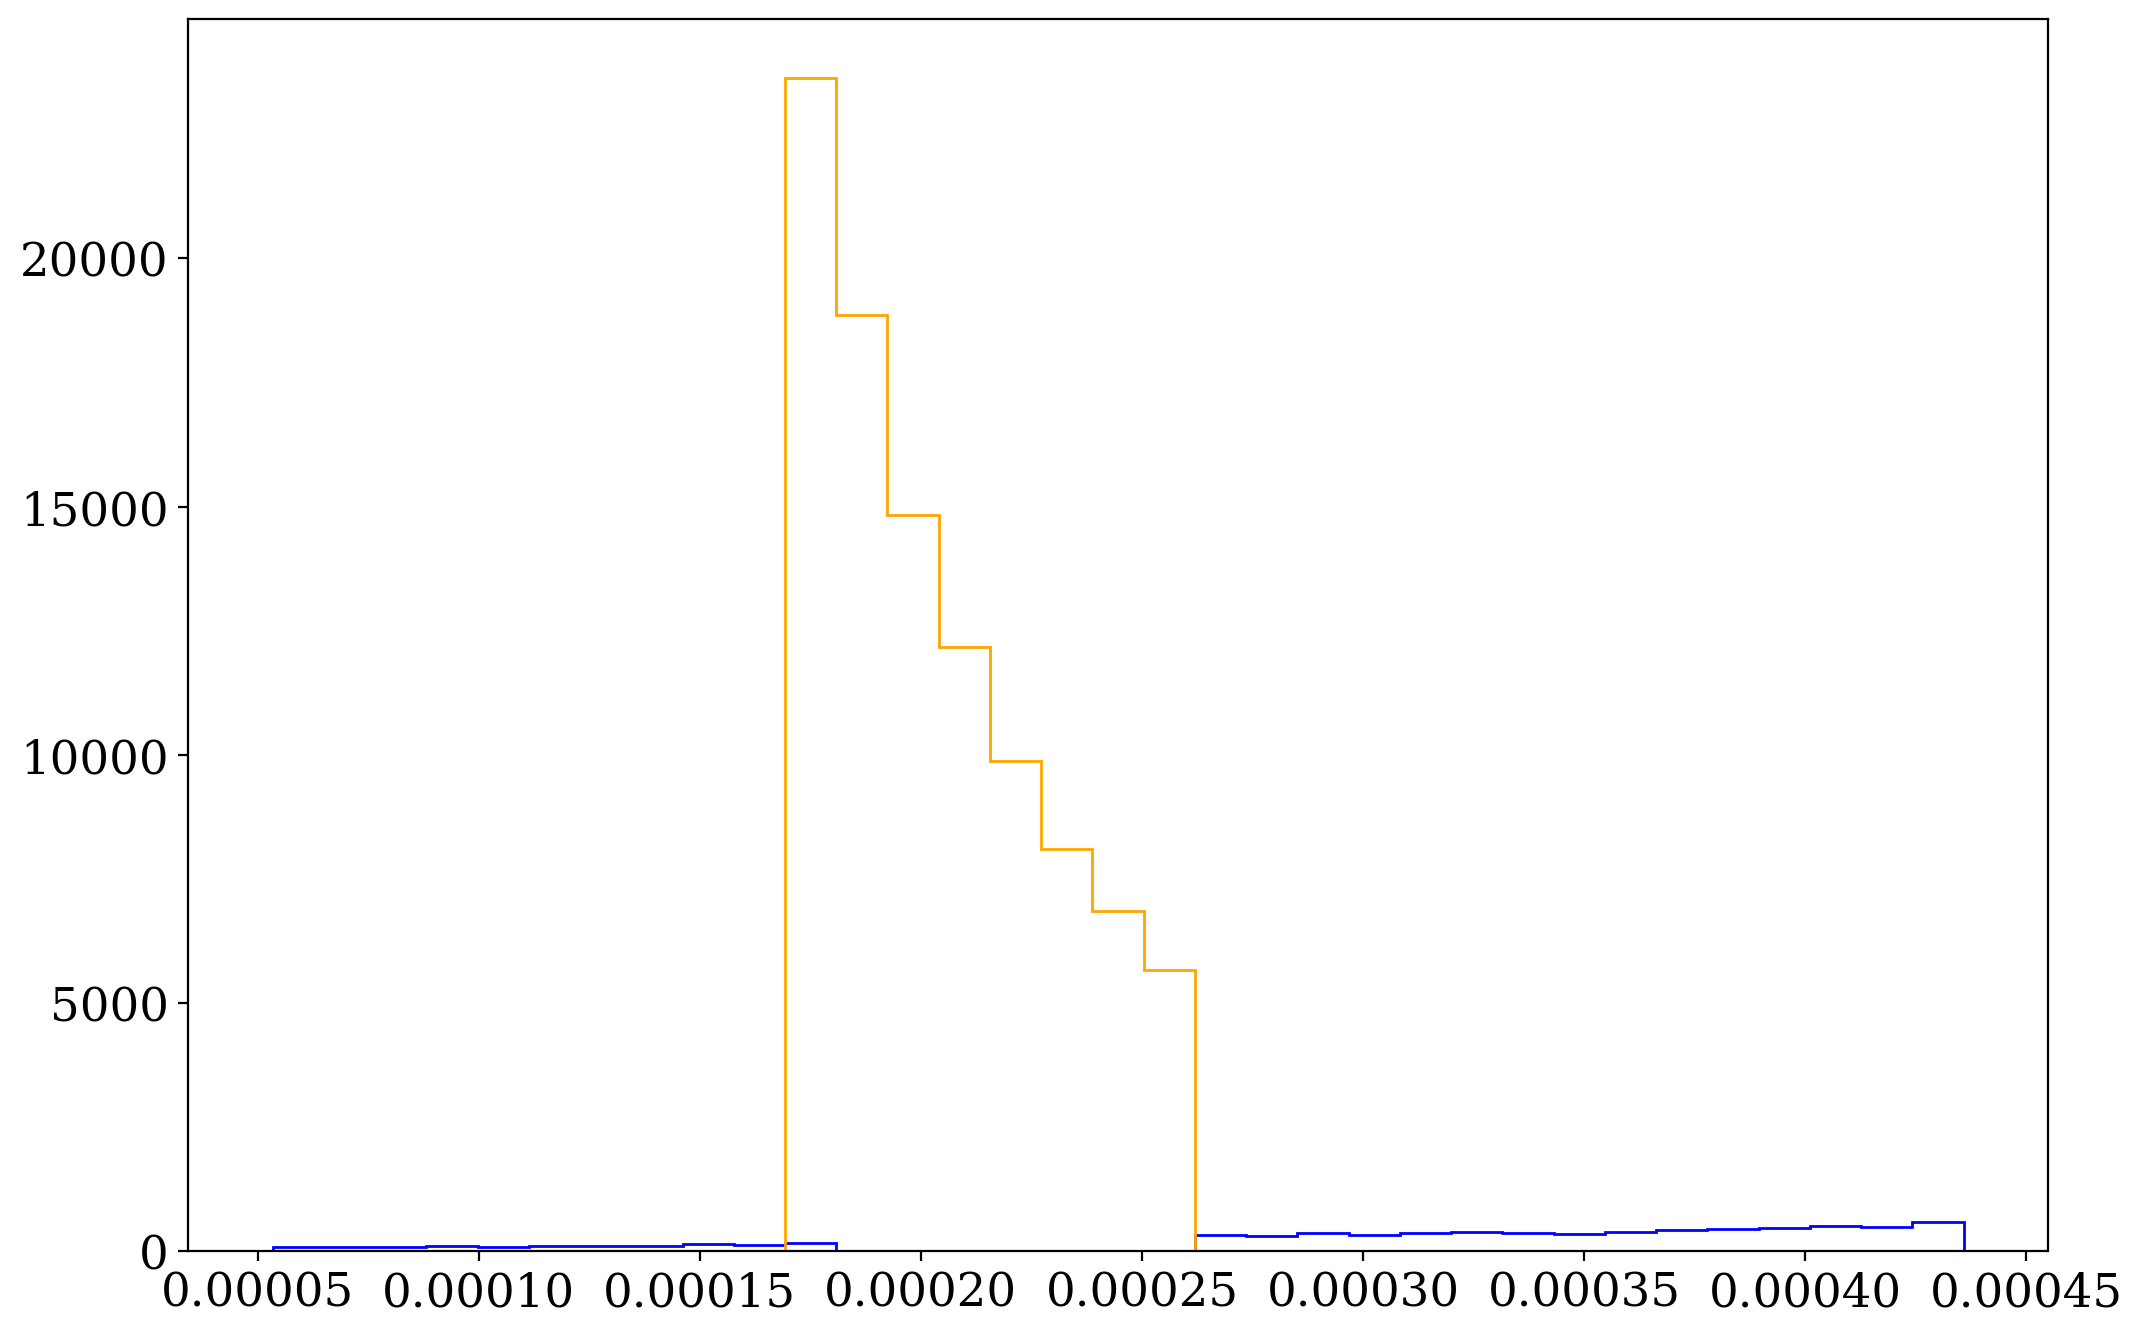

In [5]:
# LSS note that this is 33 bins bc bins includes right most edge
CV_freqbins = np.linspace(np.min(CV_pop[' f_gw[Hz]']), np.max(CV_pop[' f_gw[Hz]']), 34)
CVpopcts, _, _ = plt.hist(CV_pop[' f_gw[Hz]'], bins=CV_freqbins, histtype='step', color='blue')
fmccts, _, _ = plt.hist(fmc_draws[:, 0], bins=CV_freqbins, histtype='step', color='orange')

In [6]:
num_normfactor = fmccts/CVpopcts
num_normfactor[~np.isfinite(num_normfactor)] = 0 # set inf values to 0
num_normfactor = num_normfactor[np.where(num_normfactor > 0)[0][0]]

/tmp/ipykernel_3502931/1436678272.py:1: RuntimeWarning: divide by zero encountered in divide
  num_normfactor = fmccts/CVpopcts


In [7]:
num_normfactor

np.float64(143.24848484848485)

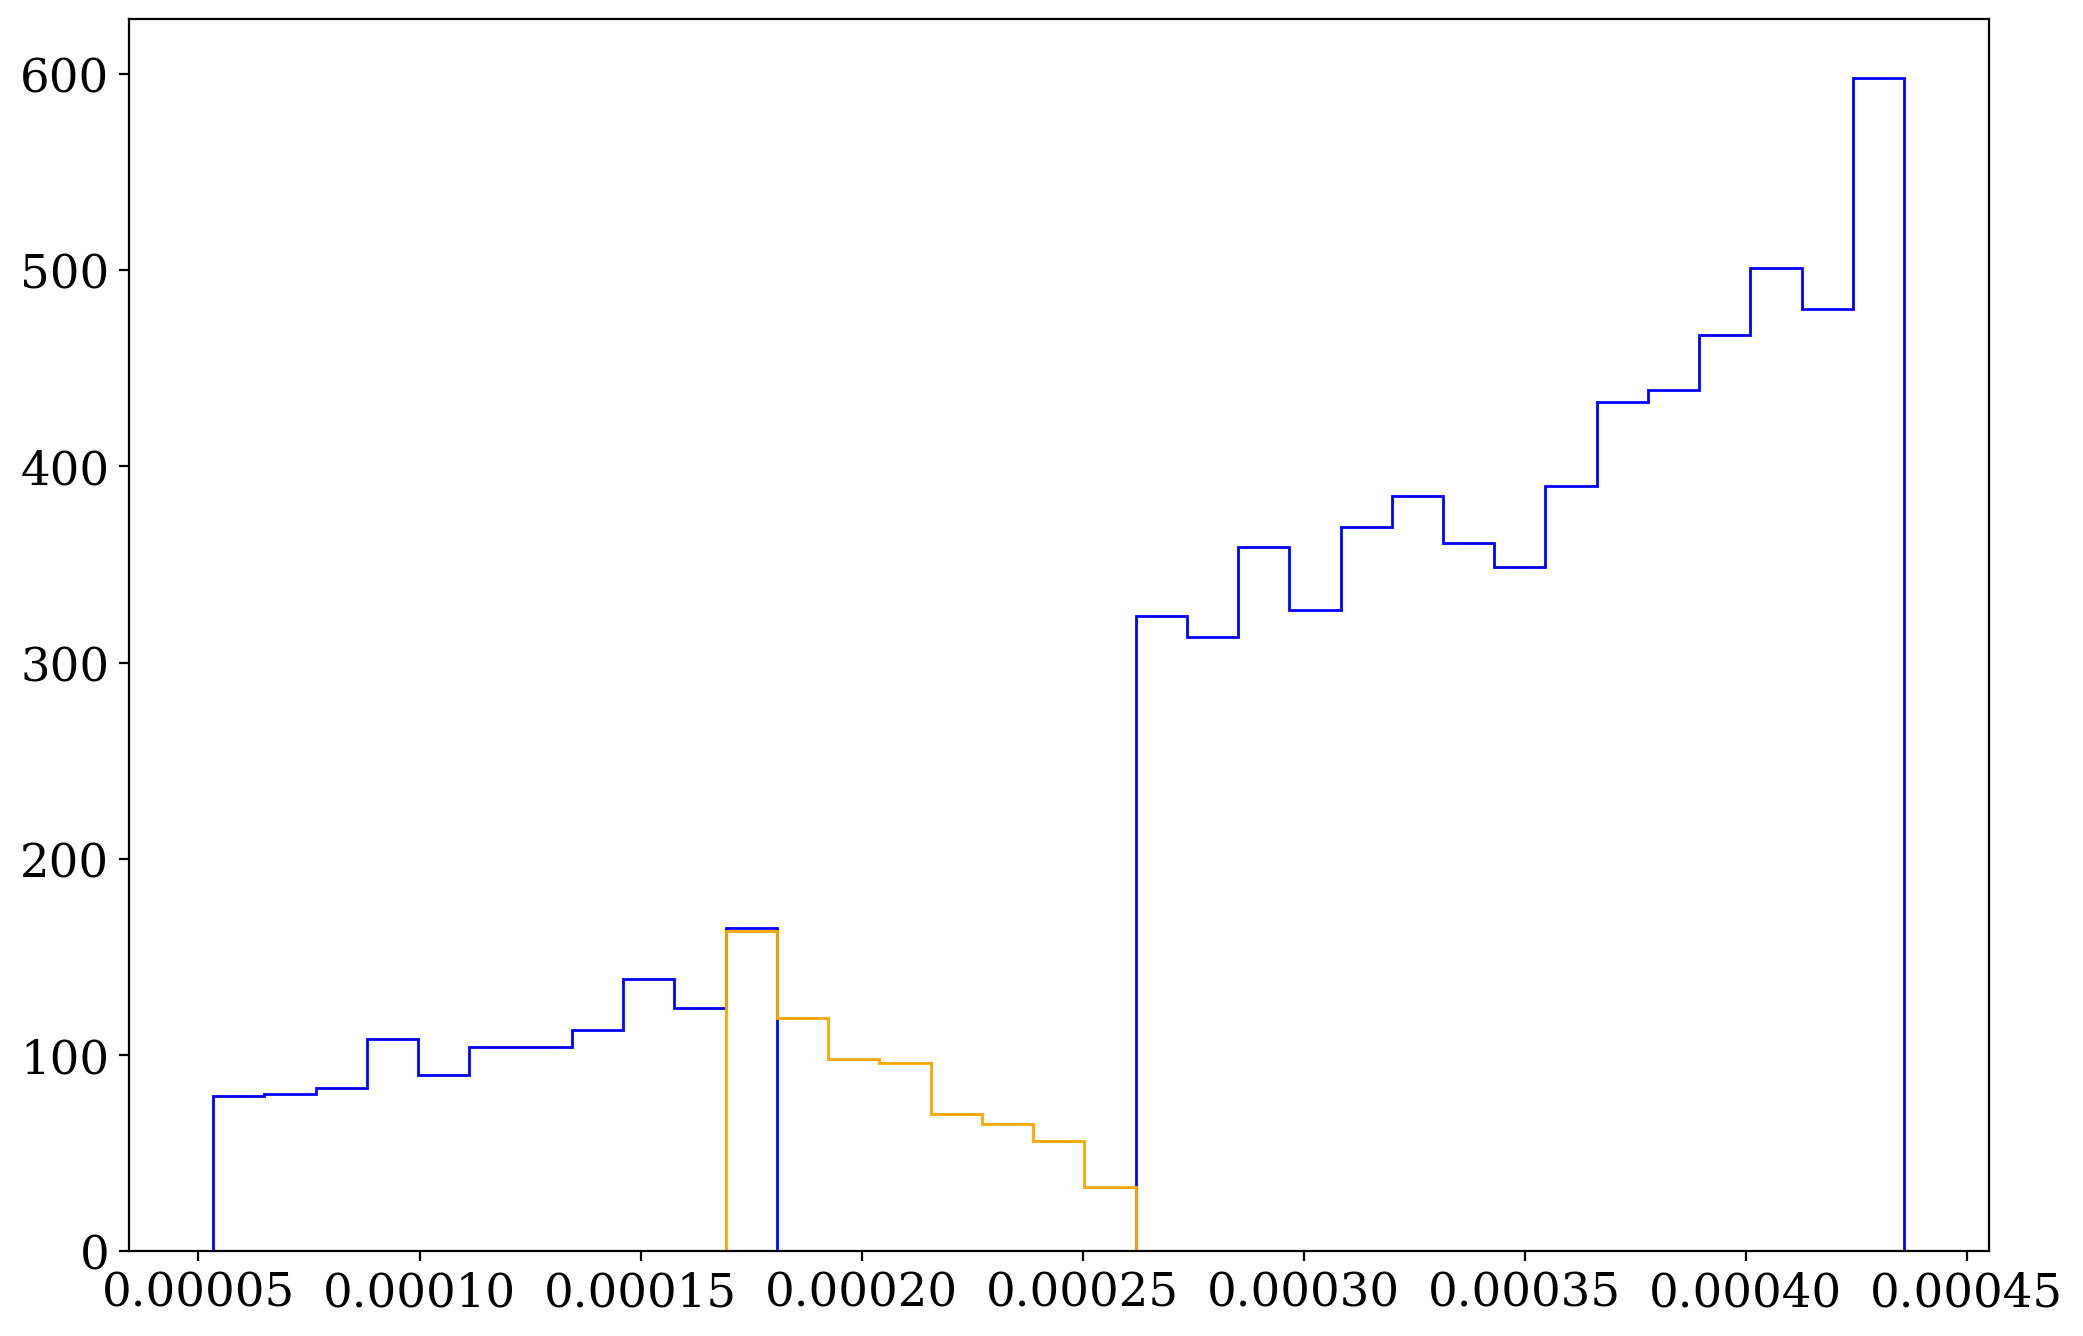

In [8]:
# LSS note that this is 33 bins bc bins includes right most edge
CV_freqbins = np.linspace(np.min(CV_pop[' f_gw[Hz]']), np.max(CV_pop[' f_gw[Hz]']), 34)
CVpopcts, _, _ = plt.hist(CV_pop[' f_gw[Hz]'], bins=CV_freqbins, histtype='step', color='blue')
fmccts, _, _ = plt.hist(fmc_draws[::int(np.round(num_normfactor)), 0], bins=CV_freqbins, histtype='step', color='orange')

In [9]:
fmccts

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 163.,
       119.,  98.,  96.,  70.,  65.,  56.,  33.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.])

In [10]:
np.where(fmccts > 0)[0][0]

np.int64(10)

In [11]:
CVpopcts

array([ 79.,  80.,  83., 108.,  90., 104., 104., 113., 139., 124., 165.,
         0.,   0.,   0.,   0.,   0.,   0.,   0., 324., 313., 359., 327.,
       369., 385., 361., 349., 390., 433., 439., 467., 501., 480., 598.])

In [12]:
fmc_downsampled = fmc_draws[::int(np.round(num_normfactor)), :]
flow_idx = np.where(fmccts > 0)[0][0]
flow = CV_freqbins[flow_idx]
df = CV_freqbins[1] - CV_freqbins[0]

In [13]:
fmc_gap = fmc_downsampled[fmc_downsampled[:, 0] > flow+df]

(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         119.,  98.,  96.,  70.,  65.,  56.,  33.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]]),
 array([5.33372000e-05, 6.49287576e-05, 7.65203152e-05, 8.81118727e-05,
        9.97034303e-05, 1.11294988e-04, 1.22886545e-04, 1.34478103e-04,
        1.46069661e-04, 1.57661218e-04, 1.69252776e-04, 1.80844333e-04,
        1.92435891e-04, 2.04027448e-04, 2.15619006e-04, 2.27210564e-04,
        2.38802121e-04, 2.50393679e-04, 2.61985236e-04, 2.73576794e-04,
        2.85168352e-04, 2.96759909e-04, 3.08351467e-04, 3.19943024e-04,
        3.31534582e-04, 3.43126139e-04, 3.54717697e-04, 3.66309255e-04,
        3.77900812e-04, 3.89492370e-04, 4.

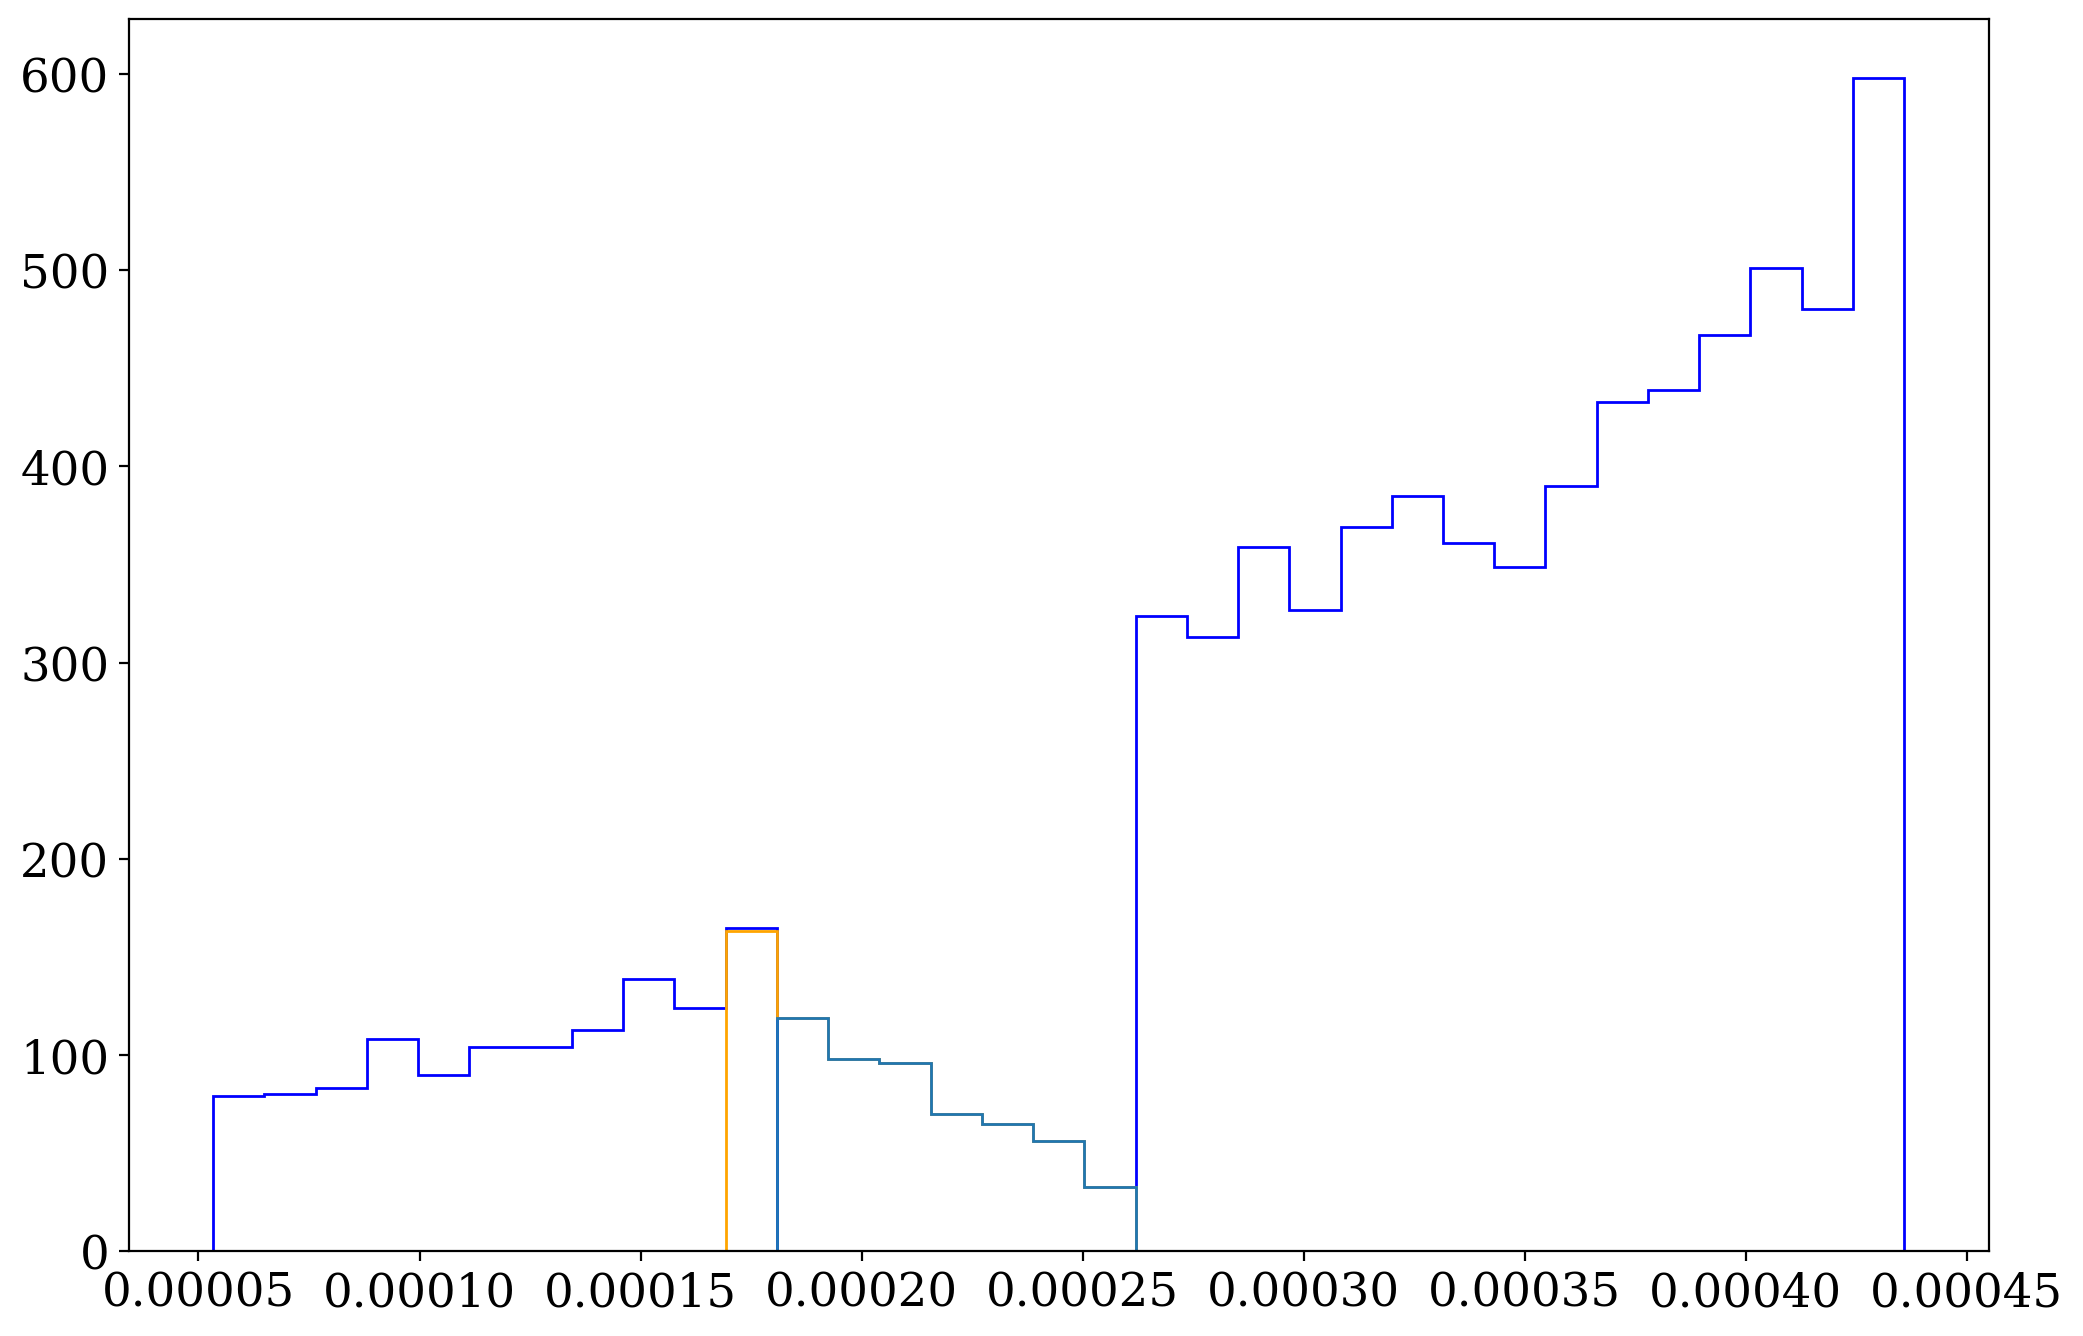

In [14]:
# LSS note that this is 33 bins bc bins includes right most edge
CV_freqbins = np.linspace(np.min(CV_pop[' f_gw[Hz]']), np.max(CV_pop[' f_gw[Hz]']), 34)
CVpopcts, _, _ = plt.hist(CV_pop[' f_gw[Hz]'], bins=CV_freqbins, histtype='step', color='blue')
fmccts, _, _ = plt.hist(fmc_draws[::int(np.round(num_normfactor)), 0], bins=CV_freqbins, histtype='step', color='orange')
plt.hist(fmc_gap, bins=CV_freqbins, histtype='step')

In [15]:
fmc_gap.shape

(537, 2)

In [16]:
np.random.seed(41) # for reproducibility
# LSS the original Scaringi paper uses seed=42 to get 7284 CVs/positions.
# LSS I want to normalize my population to the same space density and assign those
# CVs positions
max_dist = 1000 # u.kpc

x, y, z = sample_position_from_Pala_2020(dist_max=1000)

In [17]:
draw_pos_idx = np.random.choice(x.shape[0], size=fmc_gap.shape[0], replace=False)

In [27]:
fmc_x = x[draw_pos_idx]
fmc_y = y[draw_pos_idx]
fmc_z = z[draw_pos_idx]
## convert to distances and lat/long ecliptic coords
gc = cc.SkyCoord(fmc_x*u.kpc,fmc_y*u.kpc,fmc_z*u.kpc, frame='galactic', representation_type='cartesian')
SSBc = gc.transform_to(cc.BarycentricMeanEcliptic)

In [28]:
## get latitude, longitude
lat = SSBc.lat.to(u.rad).value
long = SSBc.lon.to(u.rad).value

In [34]:
xG, yG, zG = CV_pop[' x_gal[kpc]'].to_numpy(), CV_pop[' y_gal[kpc]'].to_numpy(), CV_pop[' z_gal[kpc]'].to_numpy()
## convert to distances and lat/long ecliptic coords
gc_CVpop = cc.SkyCoord(x=xG*u.kpc,y=yG*u.kpc,z=zG*u.kpc, frame='galactocentric')
SSBc_CVpop = gc_CVpop.transform_to(cc.BarycentricMeanEcliptic)
## get latitude, longitude
lat_CVpop = SSBc_CVpop.lat.to(u.rad).value
long_CVpop = SSBc_CVpop.lon.to(u.rad).value

<Figure size 1200x800 with 0 Axes>

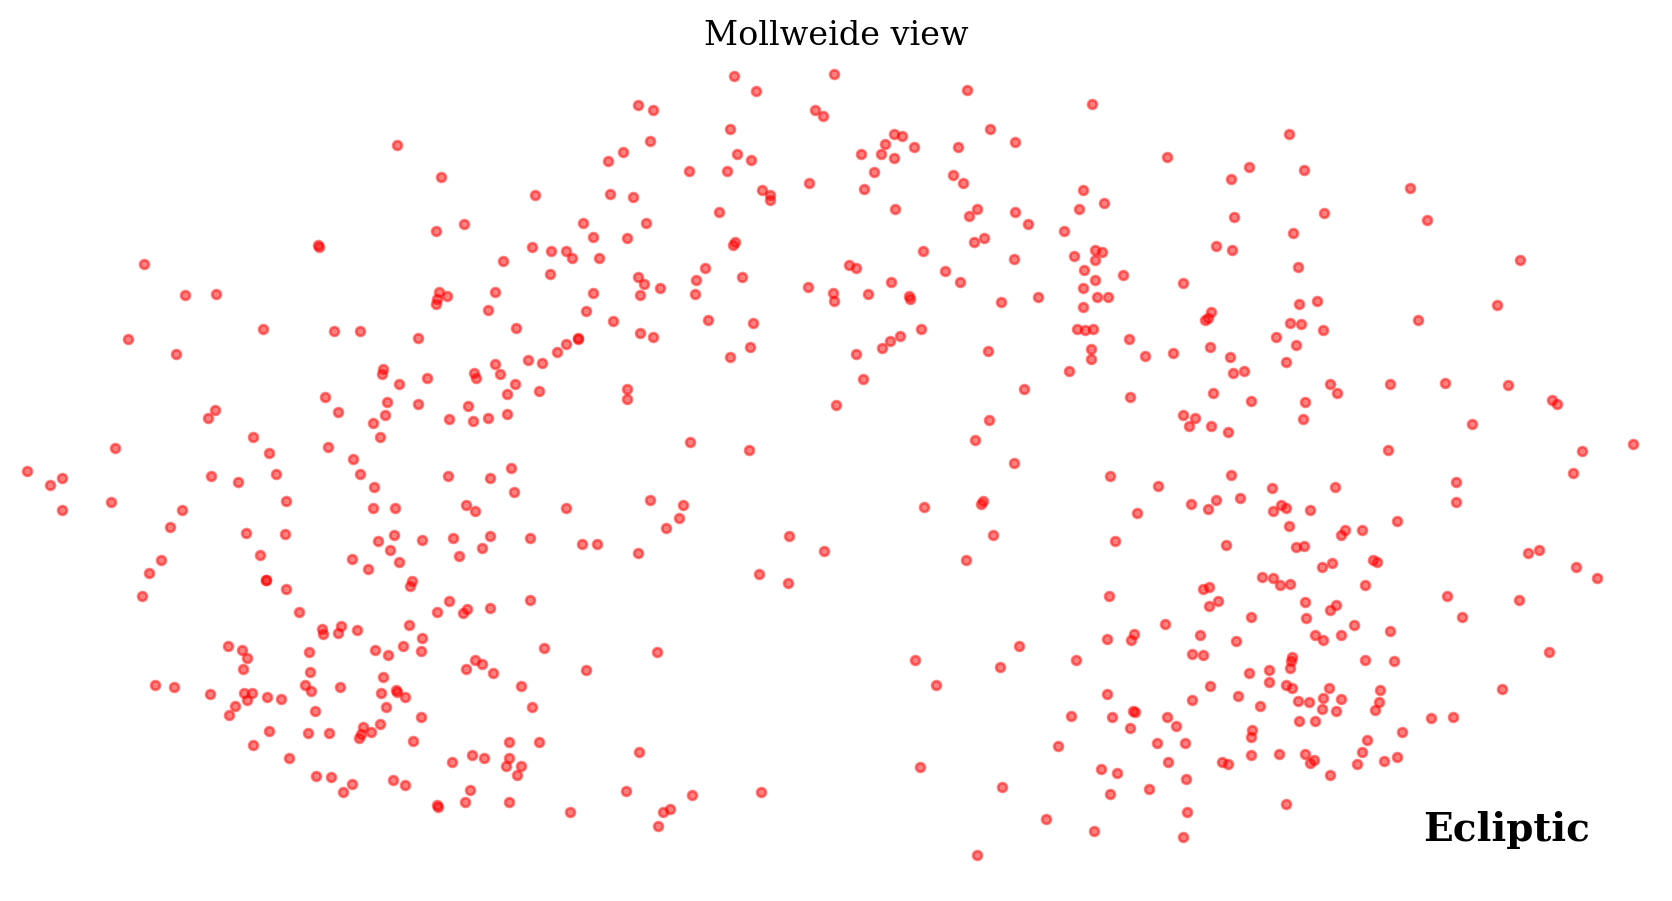

In [36]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long*u.rad.to(u.deg),lat*u.rad.to(u.deg),lonlat=True,color='r',alpha=0.5,s=10)
plt.show()

<Figure size 1200x800 with 0 Axes>

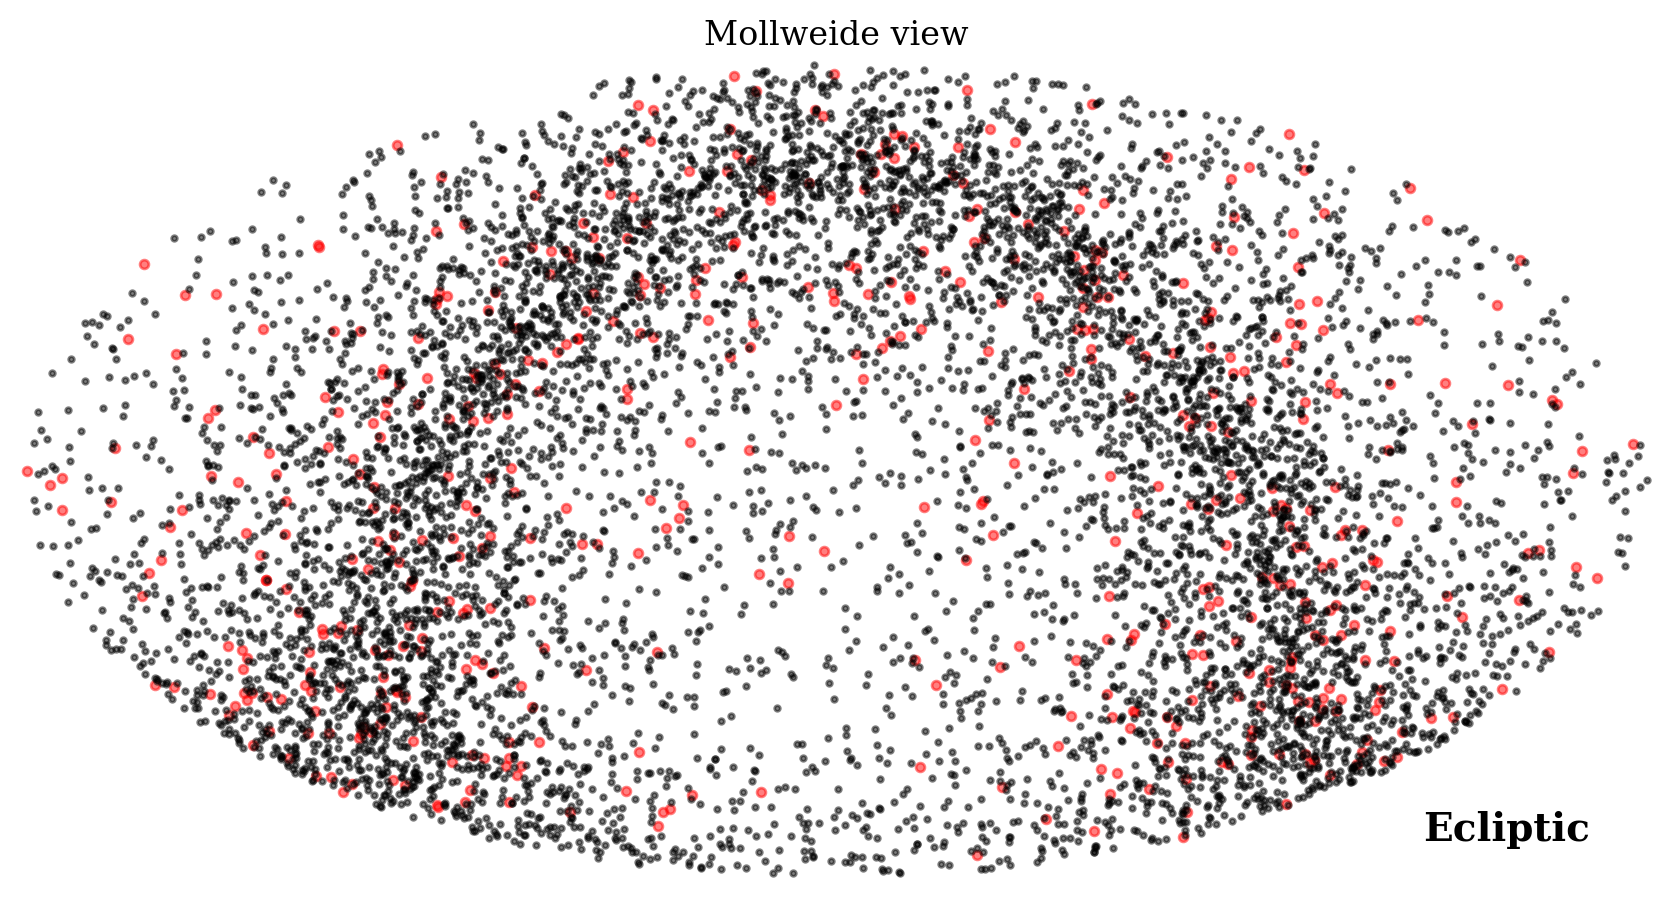

In [33]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long*u.rad.to(u.deg),lat*u.rad.to(u.deg),lonlat=True,color='r',alpha=0.5,s=10)
hp.projscatter(long_CVpop*u.rad.to(u.deg),lat_CVpop*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

In [37]:
dat = np.vstack((fmc_gap[:, 0], fmc_gap[:, 1], x[draw_pos_idx], y[draw_pos_idx], z[draw_pos_idx])).T

In [38]:
dat.shape

(537, 5)

In [39]:
np.save('fmc_gap_seed42_with_positions_seed41_20260223.npy', dat)